# Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy import stats
from sklearn.metrics import mean_squared_error

from src.eda import eta_squared
from src.features import add_band_availability, add_cation_ratio, add_missing_indicators
from src.modeling.explain import compute_shap_values

train = pd.read_csv("data/raw/train.csv", index_col="sample_id")
train = add_missing_indicators(train)
train = add_band_availability(train)
train = add_cation_ratio(train)

X = train.drop(columns=["property_organic_content"])
y = train["property_organic_content"]

test = pd.read_csv("data/raw/test.csv", index_col="sample_id")
test = add_missing_indicators(test)
test = add_band_availability(test)
test = add_cation_ratio(test)

bundle = joblib.load("outputs/final_model_bundle.pkl")
model = bundle["model"]
cat_feats = bundle["cat_feats"]

study = joblib.load("outputs/study.pkl")

shap_values = compute_shap_values(model, X, cat_feats)

c:\Users\ASUS\miniconda3\envs\compfest_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# RQ1
---
Dalam konteks bisnis pertanian dan kebijakan pangan, apakah memprediksi kandungan organik tanah merupakan hal yang mendesak? Jelaskan urgensinya dari perspektif efisiensi biaya operasional dan manajemen lahan berkelanjutan!

> Ya, prediksi kandungan bahan organik tanah merupakan hal yang sangat mendesak — terutama dalam konteks pertanian Indonesia yang masih menghadapi ketimpangan akses teknologi dan ancaman degradasi lahan yang serius. Urgensinya dapat dilihat dari dua dimensi utama.

## Efisiensi Biaya Operasional

Metode konvensional pengukuran bahan organik tanah seperti metode **Walkley-Black** atau **Loss on Ignition** memerlukan prosedur laboratorium yang memakan waktu satu hingga empat minggu dengan biaya per sampel yang dapat mencapai ratusan ribu hingga jutaan rupiah. Bagi petani kecil maupun pemerintah daerah yang perlu memetakan kesuburan tanah di ribuan titik lokasi, biaya ini menjadi hambatan struktural yang cukup signifikan.

Model prediksi berbasis *machine learning* mengubah paradigma ini secara mendasar. Setelah model dibangun dan divalidasi, pendekatan berbasis data ini menawarkan solusi yang hemat biaya dan efisien untuk pemantauan tanah berskala luas, inferensi untuk satu titik lokasi baru hanya membutuhkan data spektral dan koordinat geografis. Kemajuan teknologi digital, termasuk penginderaan jauh berbasis satelit dan kecerdasan buatan, kini semakin terjangkau dan berpotensi membuka akses *precision agriculture* bagi petani kecil di negara berkembang yang selama ini hanya terjangkau oleh agribisnis skala besar (UNDP, 2021).

Dengan mengetahui kandungan organik secara akurat dan cepat, petani dapat menghindari pemupukan berlebih yang menyebabkan nutrisi masuk ke sungai dan danau melalui limpasan, memicu blooming alga, dan mencemari sumber air minum (NDSU Extension, 2025). Dari perspektif kebijakan pangan nasional, peta digital kandungan organik yang murah dan cepat diperbarui memungkinkan pemerintah merancang program subsidi pupuk yang lebih tepat sasaran, serta mengidentifikasi wilayah dengan potensi produktivitas tertinggi untuk pengembangan lumbung pangan.

## Manajemen Lahan Berkelanjutan

Bahan organik tanah memainkan peran sentral dalam menjaga kesehatan tanah secara menyeluruh yaitu meningkatkan struktur fisik tanah, kapasitas retensi air, ketersediaan hara, dan aktivitas mikrobiologi yang menopang kesuburan jangka panjang (Omokaro et al, 2024). Selain itu, bahan organik tanah merupakan indikator kunci kesehatan tanah yang berdampak langsung pada retensi air dan nutrisi, struktur tanah, serta komunitas mikroba. Penurunan kandungan bahan organik yang tidak terdeteksi secara dini berkorelasi langsung dengan degradasi produktivitas jangka panjang yang sulit dan mahal untuk dipulihkan.

Indonesia menghadapi ancaman nyata dalam hal ini: luas lahan terdegradasi diperkirakan mencapai 24,3 hingga 48,3 juta hektar, terutama di wilayah upland dan enklave hutan (KLHK, 2023). Perluasan lahan pertanian subsisten turut mempercepat degradasi ini, dengan lebih dari 80 persen lahan pertanian dilaporkan mengalami erosi dan penurunan bahan organik tanah. Dalam konteks ini, kemampuan memantau kandungan organik secara cepat dan masif bukan lagi pilihan, melainkan kebutuhan strategis — baik untuk ketahanan pangan jangka panjang maupun komitmen Indonesia terhadap Sustainable Development Goals (SDGs), khususnya tujuan ke-2 (*Zero Hunger*) dan ke-15 (*Life on Land*).

Selain itu, bahan organik tanah adalah salah satu *pool* penyimpanan karbon terbesar di ekosistem darat. Pemantauan yang akurat dan terjangkau membuka peluang bagi Indonesia untuk mengintegrasikan sektor pertanian dengan agenda mitigasi perubahan iklim melalui skema *soil carbon sequestration* — sebuah peluang yang semakin relevan seiring meningkatnya pasar karbon global.

## Sintesis

Prediksi kandungan bahan organik tanah berbasis ML pada dasarnya mengubah peubah yang lambat dan mahal diukur menjadi sinyal yang dapat direspons secara *real-time*. Kombinasi efisiensi biaya yang drastis, jangkauan spasial yang luas, dan kemampuan pembaruan berkala menjadikan teknologi ini tidak hanya relevan secara akademis, tetapi juga transformatif secara praktis — baik bagi petani di lapangan maupun bagi pengambil kebijakan di tingkat nasional.

# RQ2
---
Apakah model prediksi kandungan organik tanah Anda mengalami overfit atau underfit? Tunjukkan buktinya secara empiris melalui metrik evaluasi atau melalui visualisasi yang relevan, serta jelaskan langkah mitigasi yang Anda lakukan! Jika tidak mengalami keduanya, jelaskan alasannya!

In [3]:
train.property_organic_content.describe()

count    11210.000000
mean        34.142518
std         23.198610
min          2.157373
25%         18.121936
50%         27.506510
75%         43.686810
max        195.231500
Name: property_organic_content, dtype: float64

In [8]:
print(f"RMSE CV: {study.best_value}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y, model.predict(X)))}")

RMSE CV: 11.933022418485706
RMSE Train: 3.2704389140397723


Untuk menjawab apakah model mengalami *overfit* atau *underfit*, evaluasi dilakukan melalui desain validasi bertingkat (*nested validation*), bukan hanya berdasarkan satu pembagian data latih dan uji. Sebelum menentukan skema validasi, terlebih dahulu diverifikasi bahwa seluruh nilai `source_id` pada data uji juga muncul pada data latih. Dengan demikian, tugas generalisasi pada kompetisi ini adalah memprediksi sampel baru yang berasal dari sumber data yang telah dikenal, bukan melakukan generalisasi terhadap sumber yang sama sekali baru. Pengecekan ini penting karena estimasi performa berbasis *k*-fold acak dapat menjadi terlalu optimist apabila sumber data yang sama muncul pada fold pelatihan dan validasi, terutama ketika tujuan evaluasi adalah mengukur kemampuan generalisasi ke sumber yang belum pernah diamati (Leinonen et al., 2024). Karena kondisi tersebut tidak berlaku pada dataset ini, Stratified K-Fold dipilih sebagai skema validasi utama yang paling representatif terhadap mekanisme evaluasi kompetisi, sedangkan GroupKFold berbasis `source_id` digunakan secara terpisah sebagai analisis diagnostik untuk mengukur ketergantungan model terhadap karakteristik masing-masing sumber data.

Hasil evaluasi menunjukkan bahwa model akhir memperoleh RMSE sebesar **3,270** pada data pelatihan, RMSE rata-rata **11,933** pada validasi *k*-fold hasil optimasi Optuna, dan RMSE **12,363** pada data uji kompetisi (*public leaderboard*). Nilai RMSE pada data pelatihan yang jauh lebih rendah menunjukkan bahwa model mampu menyesuaikan diri dengan pola pada data latih secara sangat baik. Namun, kemampuan generalisasi model lebih tepat dinilai berdasarkan konsistensi antara hasil validasi silang dan performa pada data uji yang benar-benar belum pernah dilihat. Dalam penelitian ini, selisih RMSE antara validasi *k*-fold dan *public leaderboard* hanya sebesar **0,430** atau sekitar **3,6%**, sehingga tidak terjadi penurunan performa yang signifikan pada data baru. Dengan demikian, meskipun terdapat perbedaan yang cukup besar antara RMSE data latih dan data validasi, model tidak menunjukkan indikasi *overfitting* yang berdampak signifikan terhadap kemampuan generalisasi. Di sisi lain, model juga tidak mengindikasikan *underfitting* karena mampu mencapai performa yang konsisten pada validasi silang maupun data uji.

Sebagai langkah mitigasi, kompleksitas model dikendalikan melalui optimasai *hyperparameter* CatBoost menggunakan Optuna dengan objektif berbasis *3-fold Stratified Cross-Validation*. Setiap kombinasi *hyperparameter* dievaluasi berdasarkan rata-rata RMSE pada tiga fold validasi sehingga konfigurasi terbaik dipilih berdasarkan kemampuan generalisasi, bukan semata-mata performa pada data pelatihan. Parameter yang memengaruhi kompleksitas model, seperti `depth`, `min_data_in_leaf`, `bootstrap_type`, `subsample`, dan `colsample_bylevel` (jika didukung oleh perangkat yang digunakan), dioptimalkan secara sistematis untuk memperoleh keseimbangan antara bias dan varians. Selain itu, pada setiap fold validasi diterapkan mekanisme *early stopping* (`early_stopping_rounds=50`) sehingga proses pembentukan *tree* dihentikan ketika performa pada data validasi tidak lagi mengalami peningkatan. CatBoost juga digunakan tanpa melakukan imputasi nilai hilang karena algoritma ini mampu menangani *missing value* secara native. Kombinasi strategi tersebut menghasilkan estimasi performa yang lebih andal dan membantu menjaga kemampuan generalisasi model, sebagaimana ditunjukkan oleh konsistensi antara RMSE validasi silang sebesar **11,933** dan RMSE pada *public leaderboard* sebesar **12,363**.

Daftar pustaka untuk RQ1:

Kapoor, S., & Narayanan, A. (2023). Leakage and the reproducibility crisis in machine-learning-based science. Patterns, 4. https://doi.org/10.1016/j.patter.2023.100804
Leinonen, T., Wong, D., Vasankari, A., Wahab, A., Nadarajah, R., Kaisti, M., & Airola, A. (2024). Empirical investigation of multi-source cross-validation in clinical ECG classification. Computers in Biology and Medicine, 183, 109271. https://doi.org/10.1016/j.compbiomed.2024.109271

# RQ3
---
Apakah ada pola distribusi kandungan organik tanah yang berbeda secara signifikan antar wilayah geografis? Berdasarkan pola tersebut, kira-kira kondisi ekosistem seperti apa yang paling dominan dalam dataset ini? Jelaskan reasoning Anda berdasarkan informasi ekologis dan tutupan lahan yang terlihat!

In [3]:
# Rata-rata, median, std kandungan organik per wilayah makro
geo_summary = (
    train.groupby("geo_zone_macro")["property_organic_content"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)
print(geo_summary)

                count       mean     median        std
geo_zone_macro                                        
S                1022  57.266801  55.789674  36.452029
NE                512  42.367177  35.192152  31.220322
MW               2930  34.500503  29.124540  20.587121
N                 979  34.394741  30.742570  19.625071
SE               5767  29.089654  24.270450  17.819009


In [4]:
# Uji ANOVA satu arah: apakah perbedaan rata-rata antar wilayah signifikan?
groups_macro = [g["property_organic_content"].values for _, g in train.groupby("geo_zone_macro")]
f_macro, p_macro = stats.f_oneway(*groups_macro)
print(f"ANOVA geo_zone_macro\nF = {f_macro:.2f}, p-value = {p_macro:.3g}")

groups_biome = [g["property_organic_content"].values for _, g in train.groupby("biome")]
f_biome, p_biome = stats.f_oneway(*groups_biome)
print(f"\nANOVA biome\nF = {f_biome:.2f}, p-value = {p_biome:.3g}")

ANOVA geo_zone_macro
F = 384.94, p-value = 3.46e-311

ANOVA biome
F = 5.58, p-value = 0.000173


> ANOVA menunjukkan perbedaan rata-rata antar `geo_zone_macro` signifikan (p < 0.001).

In [5]:
# Distribusi kandungan organik per tipe tutupan lahan (land_cover_type)
landcover_summary = (
    train.groupby("land_cover_type")["property_organic_content"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)
print(landcover_summary)

                               count       mean     median        std
land_cover_type                                                      
Seasonal Semideciduous Forest   3446  27.667800  22.652420  17.279683
Savannah                        3019  35.050507  30.742570  19.318495
Unknown                         1893  34.121648  27.506510  24.525467
Areas of Ecological Tension     1240  33.187183  28.072820  18.485415
Dense Ombrophylous Forest        653  35.432299  27.506510  26.494566
Seasonal Deciduous Forest        521  69.180513  65.125708  35.766982
Areas of Pioneering Formation    194  22.857176  22.652420  10.207491
Mixed Ombrophylous Forest         85  74.248605  77.843423  32.168497
Steppe                            77  45.098279  38.266410  27.512613
Open Ombrophylous Forest          50  42.139398  36.162971  30.804470
Amazon Rainforest                 32  10.225556   8.701406   5.989948


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13692\3593629050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='geo_zone_macro', y="property_organic_content", order=order, palette='Blues_r')


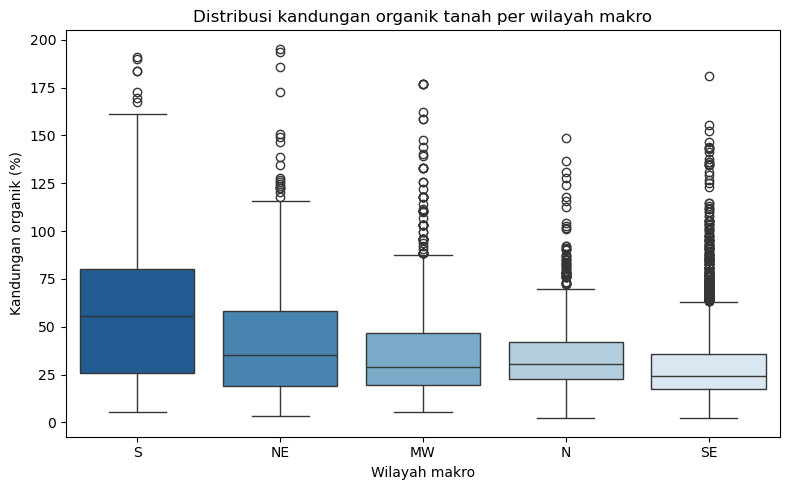

In [6]:
# Visualisasi: boxplot kandungan organik per wilayah makro
plt.figure(figsize=(8, 5))
order = train.groupby('geo_zone_macro')["property_organic_content"].mean().sort_values(ascending=False).index
sns.boxplot(data=train, x='geo_zone_macro', y="property_organic_content", order=order, palette='Blues_r')
plt.title('Distribusi kandungan organik tanah per wilayah makro')
plt.xlabel('Wilayah makro')
plt.ylabel('Kandungan organik (%)')
plt.tight_layout()
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13692\2400153967.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


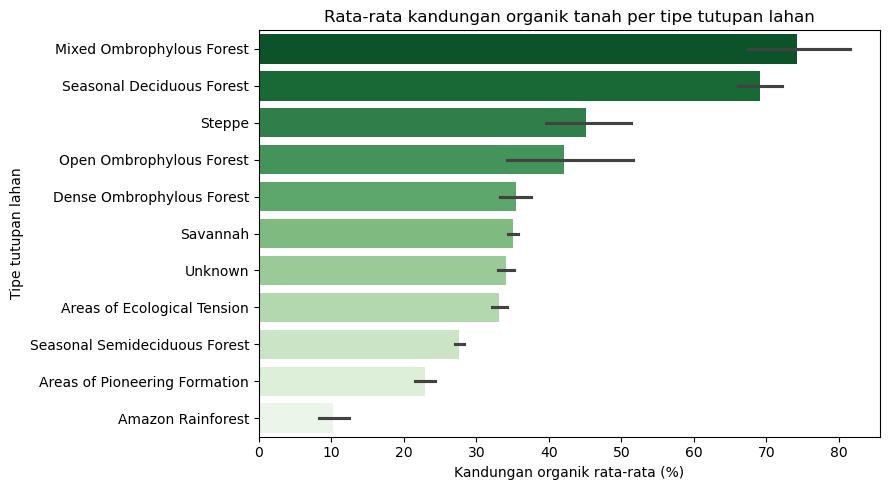

In [7]:
# Visualisasi: rata-rata kandungan organik per tipe tutupan lahan
plt.figure(figsize=(9, 5))
lc_order = landcover_summary.sort_values("mean", ascending=False).index
sns.barplot(
    data=train,
    x="property_organic_content",
    y="land_cover_type",
    order=lc_order,
    estimator=np.mean,
    errorbar=("ci", 95),
    palette="Greens_r",
)
plt.title("Rata-rata kandungan organik tanah per tipe tutupan lahan")
plt.xlabel("Kandungan organik rata-rata (%)")
plt.ylabel("Tipe tutupan lahan")
plt.tight_layout()
plt.show()

* Wilayah **S (Selatan)** memiliki kandungan organik rata-rata tertinggi
* Wilayah **SE (Tenggara)** memiliki kandungan organik rata-rata terendah, sekaligus mendominasi jumlah sampel dalam dataset.

* Tipe tutupan lahan **Savannah** dan **Seasonal Semideciduous Forest** paling dominan secara jumlah sampel, mencerminkan dominasi bioma Cerrado dan Mata Atlantica dalam dataset ini. Pada ekosistem savana tropis musiman dan hutan semi-gugur, suhu musiman yang tinggi mempercepat laju respirasi mikroba sehingga dekomposisi serasah berlangsung relatif cepat, sejalan dengan temuan Silva et al. (2019), yang berkontribusi pada kandungan organik rata-rata yang rendah hingga menengah.
* Sebaliknya, wilayah berhutan lembap (sebagian besar wilayah S dan Amazonia) merupakan minoritas dalam dataset namun menunjukkan kandungan organik jauh lebih tinggi, karena kelembapan tinggi menghambat laju dekomposisi bahan organik sehingga akumulasinya lebih besar (Amundson et al., 2015).

# RQ4
---
Apakah ada korelasi kandungan organik tanah antar tingkat wilayah geografis? Berapa rasio perbandingan rata-rata kandungan organik antar wilayah tersebut, dan bagaimana ini memengaruhi pendekatan pemodelan Anda?

In [8]:
for col in ["geo_zone_macro", "geo_zone_meso", "geo_zone_micro"]:
    eta, n_cat = eta_squared(train, group_col=col, target_col="property_organic_content")
    print(f"{col}: eta^2 = {eta:.4f} (n_kategori = {n_cat})")

geo_zone_macro: eta^2 = 0.1208 (n_kategori = 5)
geo_zone_meso: eta^2 = 0.2747 (n_kategori = 23)
geo_zone_micro: eta^2 = 0.2734 (n_kategori = 50)


In [9]:
# Cek apakah geo_zone_meso benar-benar nested (1 meso hanya milik 1 macro)
nested_check = train.groupby("geo_zone_meso")["geo_zone_macro"].nunique()
print(
    "Jumlah meso-zone yang lintas wilayah macro:",
    (nested_check > 1).sum(),
    "dari",
    len(nested_check),
    "meso-zone",
)

Jumlah meso-zone yang lintas wilayah macro: 0 dari 23 meso-zone


In [10]:
# Rasio rata-rata kandungan organik antar wilayah makro
means_macro = (
    train.groupby("geo_zone_macro")["property_organic_content"]
    .mean()
    .sort_values(ascending=False)
)

print(means_macro)
print()
print(
    "Rasio tertinggi/terendah (S / SE):",
    round(means_macro.max() / means_macro.min(), 3),
)

geo_zone_macro
S     57.266801
NE    42.367177
MW    34.500503
N     34.394741
SE    29.089654
Name: property_organic_content, dtype: float64

Rasio tertinggi/terendah (S / SE): 1.969


* `geo_zone_meso` (level state) menjelaskan proporsi keragaman kandungan organik yang jauh lebih besar dibanding `geo_zone_macro` (level wilayah besar), mengindikasikan adanya heterogenitas signifikan di dalam satu wilayah makro. Ini berarti `geo_zone_meso` lebih informatif sebagai fitur prediktor — informasi yang dapat dimanfaatkan langsung oleh CatBoost melalui penanganan fitur kategorik secara *native* tanpa encoding manual.
* Rata-rata kandungan organik wilayah **S (Selatan)** sekitar **dua kali
  lipat** lebih tinggi dibanding wilayah **SE (Tenggara)**, mencerminkan
  kesenjangan ekologis yang substansial antar wilayah ekstrem dalam dataset.

# RQ5
---

## RQ5a
---
Berapa rata-rata kandungan organik tanah dari tiap ekosistem ketika tingkat keasaman tanah berada di bawah persentil 25 dan kapasitas tukar kation berada di bawah rata-rata? Apa insight yang bisa didapat dari hal ini?

In [11]:
# Rata-rata kandungan organik per biome

# Menghitung threshold filter
p25_acidity = train["property_acidity_index"].quantile(0.25)
mean_cec = train["cation_exchange_capacity"].mean()

print(f"Persentil 25 property_acidity_index: {p25_acidity:.4f}")
print(f"Rata-rata cation_exchange_capacity: {mean_cec:.4f}")

# Menerapkan filter
df_filtered = train[
    (train["property_acidity_index"] < p25_acidity)
    & (train["cation_exchange_capacity"] < mean_cec)
].copy()

print(f"\nJumlah sampel setelah filter: {len(df_filtered)} dari {len(train)} ({100 * len(df_filtered) / len(train):.1f}%)")

Persentil 25 property_acidity_index: 12.8805
Rata-rata cation_exchange_capacity: 169.1421

Jumlah sampel setelah filter: 388 dari 11210 (3.5%)


In [12]:
# Menghitung rata-rata per biome
result = (
    df_filtered.groupby("biome")["property_organic_content"]
    .agg(rata_rata="mean", jumlah_sampel="count", std="std")
    .reset_index()
    .sort_values("rata_rata", ascending=False)
    .round(4)
)

print("Rata-rata kandungan organik per biome (acidity < P25, CEC < mean):\n")
print(result.to_string(index=False))

Rata-rata kandungan organik per biome (acidity < P25, CEC < mean):

         biome  rata_rata  jumlah_sampel     std
       Unknown    43.6868              1     NaN
      Amazonia    27.6124            197  6.7311
       Cerrado    24.2704              2  0.0000
Mata Atlantica    21.3180            186 10.0405
      Caatinga    19.9827              2  1.2585


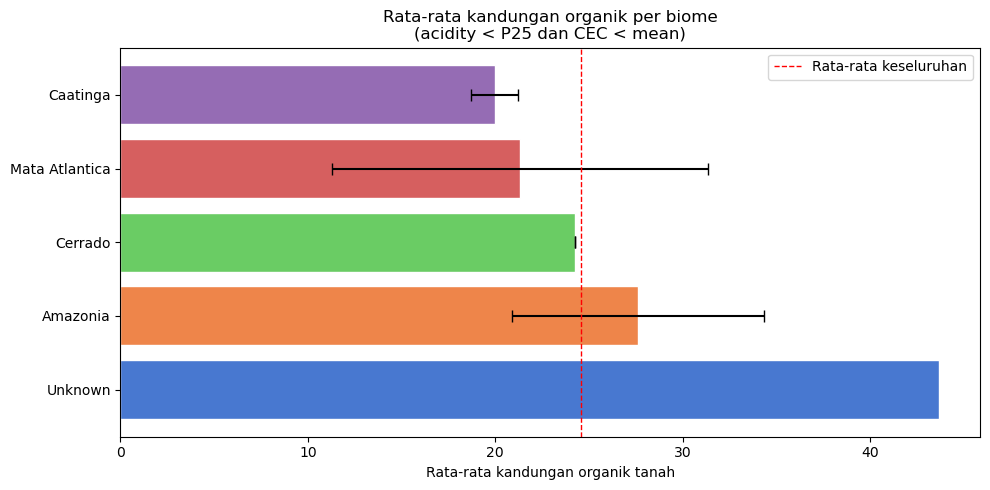

In [13]:
# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    result["biome"],
    result["rata_rata"],
    xerr=result["std"],
    color=sns.color_palette("muted", len(result)),
    edgecolor="white",
    capsize=4,
)

ax.set_xlabel("Rata-rata kandungan organik tanah")
ax.set_title("Rata-rata kandungan organik per biome\n(acidity < P25 dan CEC < mean)", fontsize=12)
ax.axvline(
    df_filtered["property_organic_content"].mean(),
    color="red",
    linestyle="--",
    linewidth=1,
    label="Rata-rata keseluruhan",
)
ax.legend()
plt.tight_layout()
plt.show()

Dari 11.210 sampel, hanya 388 sampel (3,5%) yang memenuhi kedua kondisi filtrasi secara bersamaan: keasaman di bawah persentil 25 (*acidity* < 12,88) dan kapasitas tukar kation di bawah rata-rata (CEC < 169,14). Kondisi ini merepresentasikan tanah yang relatif tidak asam sekaligus memiliki kemampuan mengikat ion yang rendah — secara agronomis menggambarkan tanah dengan aktivitas kimia yang terbatas.

Beberapa temuan utama dari visualisasi:

1. **Kategori** ***Unknown mendominasi*** **dengan nilai tertinggi (~43,7)**

   Meski tidak dapat diinterpretasikan secara ekologis, nilai ini adalah yang tertinggi di antara semua biome pada kondisi filter. Kemungkinan besar sampel ini berasal dari lokasi yang belum terklasifikasi namun memiliki akumulasi bahan organik yang signifikan.

2. **Amazonia adalah satu-satunya biome bernama yang melampaui rata-rata keseluruhan (~27,6)**

   Ini konsisten dengan karakteristik ekosistem hutan hujan tropis yang menghasilkan serasah dan biomassa tinggi. Namun nilai ini tetap lebih rendah dari rata-rata global Amazonia (33,91), mengindikasikan bahwa sampel Amazonia yang lolos filter — yaitu yang memiliki keasaman dan CEC
   rendah — bukanlah sampel dengan kandungan organik tertinggi di biome tersebut.

3. **Caatinga, Mata Atlantica, dan Cerrado berada di bawah rata-rata keseluruhan**

   Caatinga (ekosistem semi-kering) menunjukkan nilai terendah (~19,98), yang masuk akal karena produksi biomassa di ekosistem kering secara alami lebih rendah. Yang menarik, rata-rata global Caatinga justru lebih tinggi (44,90), artinya sampel Caatinga dengan kandungan organik tinggi cenderung berasosiasi dengan keasaman dan CEC yang tinggi, bukan rendah.

4. **Mata Atlantica memiliki error bar terlebar**

   Ini mencerminkan keragaman internal yang tinggi di dalam biome tersebut pada kondisi filter, kemungkinan karena Mata Atlantica mencakup berbagai
   sub-tipe vegetasi dengan kondisi tanah yang beragam.

Secara keseluruhan, pada kondisi tanah dengan keasaman rendah dan CEC rendah, hampir semua biome menunjukkan kandungan organik yang lebih rendah dibandingkan rata-rata globalnya masing-masing. Hal ini mengindikasikan bahwa kandungan bahan organik tanah yang tinggi cenderung hadir bersama keasaman dan kapasitas tukar kation yang lebih tinggi — hubungan yang secara ilmiah logis, karena dekomposisi bahan organik menghasilkan asam humat yang menurunkan pH sekaligus meningkatkan KTK tanah.

## RQ5b
---
Apakah ada kombinasi jenis tutupan lahan dan wilayah geografis tertentu yang memiliki nilai kandungan organik yang dapat dianggap sebagai *outlier*? Jelaskan justifikasi Anda!

In [14]:
# Deteksi outlier kandungan organik

# Menghitung statistik per kombinasiv
group_stats = (
    train.groupby(["land_cover_type", "geo_zone_macro"])["property_organic_content"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        count="count",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

# IQR per grup
group_stats["iqr"] = group_stats["q3"] - group_stats["q1"]
group_stats["lower_fence"] = group_stats["q1"] - 1.5 * group_stats["iqr"]
group_stats["upper_fence"] = group_stats["q3"] + 1.5 * group_stats["iqr"]

print(f"Jumlah kombinasi land_cover x geo_zone_macro: {len(group_stats)}")
group_stats.sort_values("mean", ascending=False).head(10)

Jumlah kombinasi land_cover x geo_zone_macro: 32


,land_cover_type,geo_zone_macro,mean,median,std,count,q1,q3,iqr,lower_fence,upper_fence
15,Open Ombrophylous Forest,NE,87.313522,76.160672,32.769130,7,62.625851,117.299085,54.673234,-19.383999,199.308935
13,Mixed Ombrophylous Forest,SE,84.946575,84.946575,14.644736,2,79.768879,90.124271,10.355392,64.235791,105.657359
12,Mixed Ombrophylous Forest,S,73.990822,77.843423,32.474257,83,50.846593,96.110982,45.264389,-17.049991,164.007566
4,Areas of Ecological Tension,S,71.783362,68.345587,16.576870,15,58.443244,82.430538,23.987295,22.462301,118.411480
21,Seasonal Deciduous Forest,S,71.049993,67.504212,35.850481,487,47.424459,89.129183,41.704723,-15.132626,151.686267
19,Savannah,S,70.739903,67.601293,46.173274,39,34.423588,104.492377,70.068789,-70.679595,209.595561
7,Areas of Pioneering Formation,N,67.444884,72.228859,26.066129,3,55.773494,81.508261,25.734767,17.171343,120.110412
2,Areas of Ecological Tension,N,56.740054,55.336626,28.958396,38,38.399897,72.083237,33.683340,-12.125112,122.608246
3,Areas of Ecological Tension,NE,50.751822,37.004346,44.012911,14,34.253695,50.522987,16.269292,9.849758,74.926924
10,Dense Ombrophylous Forest,NE,47.009255,36.243872,39.609330,120,15.047679,71.128599,56.080920,-69.073701,155.249978


Berikut versi yang sudah dirapikan, dengan beberapa kalimat yang strukturnya terputus atau koma-runtun (*run-on*) diperbaiki:

---

Deteksi outlier menggunakan metode IQR per kombinasi (Q1 − 1,5×IQR hingga Q3 + 1,5×IQR) menghasilkan 428 sampel outlier (3,8%) yang tersebar di 20 kombinasi tutupan lahan × wilayah geografis makro. Keenam kombinasi dengan outlier terbanyak memperlihatkan pola yang berbeda-beda secara ekologis.

**1. Seasonal Semideciduous Forest × SE - 235 outlier (terbanyak)**
Boxplot menunjukkan distribusi inti yang sangat terkonsentrasi di rentang rendah (~15–35), namun dengan ekor atas yang sangat panjang hingga ~155. Jumlah titik outlier yang begitu banyak dan padat mengindikasikan bahwa fenomena ini bukan sekadar anomali acak, melainkan cerminan dari sub-populasi sampel dengan kondisi tanah yang berbeda secara sistematis dalam kombinasi yang sama. Wilayah SE mencakup area yang sangat luas dengan intensitas penggunaan lahan yang beragam, sehingga heterogenitas ini kemungkinan mencerminkan perbedaan nyata pada kondisi lahan di lapangan.

**2. Savannah × SE - 45 outlier dengan nilai hingga ~175**
Secara ekologis, savana dikenal memiliki kandungan organik yang relatif rendah karena vegetasinya yang lebih jarang dan produksi biomassa yang terbatas. Oleh karena itu, sampel dengan nilai organik sangat tinggi pada kombinasi ini merupakan anomali ekologis yang signifikan, kemungkinan merepresentasikan area transisi menuju ekosistem yang lebih lebat, atau lokasi dengan akumulasi organik akibat kondisi hidrologi lokal seperti cekungan atau lahan basah tersembunyi.

**3. Unknown × MW - 38 outlier dengan nilai hingga ~175**
Distribusi intinya sudah lebih tinggi dibanding dua kombinasi sebelumnya (~25–55), sehingga outlier yang muncul di sini mencerminkan nilai yang benar-benar ekstrem secara absolut. Ketidakjelasan kategori tutupan lahan ("Unknown") mempersulit interpretasi ekologis, namun nilai organik setinggi ini di wilayah MW konsisten dengan kemungkinan adanya sampel dari lahan gambut atau hutan riparian yang belum terklasifikasi.

**4. Areas of Ecological Tension × MW - 31 outlier**
Ini adalah kombinasi dengan sebaran box paling sempit dan terkontrol di antara keenam kombinasi. Outlier yang muncul (~62–89) tidak terlalu jauh dari batas atas box, menandakan bahwa penyimpangan di sini lebih moderat. "Areas of Ecological Tension" merepresentasikan zona transisi antara dua bioma, sehingga variabilitas yang ada kemungkinan memang bersifat intrinsik dari karakteristik ekotonal tersebut.

**5. Seasonal Deciduous Forest × S - 18 outlier, namun paling ekstrem secara ekologis**
Kombinasi ini paling menonjol karena box-nya sendiri sudah berada di rentang tinggi (~50–100), berbeda dari kombinasi lain yang box-nya cenderung rendah. Artinya, nilai organik yang tinggi di sini bukan pengecualian, melainkan sudah menjadi norma dalam kombinasi ini. Outlier yang muncul (~155–190) bahkan jauh di atas kondisi yang sudah tinggi tersebut. Hutan gugur musiman di wilayah S kemungkinan memiliki akumulasi serasah yang intens dan kondisi kelembapan yang mendukung mineralisasi organik.

**6. Savannah × N - satu-satunya dengan outlier bawah**
Selain beberapa outlier atas (~50–80), kombinasi ini adalah satu-satunya yang memiliki outlier bawah mendekati nilai 0. Hal ini mengindikasikan adanya sampel tanah savana di wilayah N yang sangat miskin bahan organik, kemungkinan berasal dari area dengan erosi parah, penggunaan lahan intensif, atau kondisi geologi dengan pelapukan lanjut yang menyisakan sedikit material organik.

**Justifikasi metodologis**
Penggunaan IQR per kombinasi (bukan IQR global) adalah pilihan yang tepat karena memungkinkan evaluasi outlier dilakukan dalam konteks ekologis lokal masing-masing kombinasi. Nilai organik 80 mungkin normal untuk hutan lebat di S, namun ekstrem untuk savana di N; penilaian global akan kehilangan nuansa perbedaan ini. Secara praktis, keberadaan outlier ini penting untuk dipertimbangkan dalam pemodelan: alih-alih dihapus begitu saja, outlier sebaiknya ditangani melalui transformasi target (log-transform) atau penggunaan model yang secara inheren robust terhadap nilai ekstrem.

---

Beberapa perbaikan substantif: kalimat penutup di poin 4 saya susun ulang karena di teks asli strukturnya terputus ("...antardua biome variabilitas yang ada..."); beberapa kalimat yang menggabungkan dua klausa hanya dengan koma (di poin 1, poin 5, dan bagian justifikasi) saya pisah atau beri konjungsi/tanda baca yang sesuai; kata "dimana" yang dipakai sebagai penghubung di bagian justifikasi saya ganti karena bukan penggunaan baku; dan ejaan "kelembaban" distandardisasi menjadi "kelembapan" sesuai KBBI. Semua angka dan substansi data tidak saya ubah.

# RQ6
---
Apakah ada pasangan variabel yang berkorelasi tinggi? Apakah ada efek multicollinearity yang perlu diatasi dalam modeling?

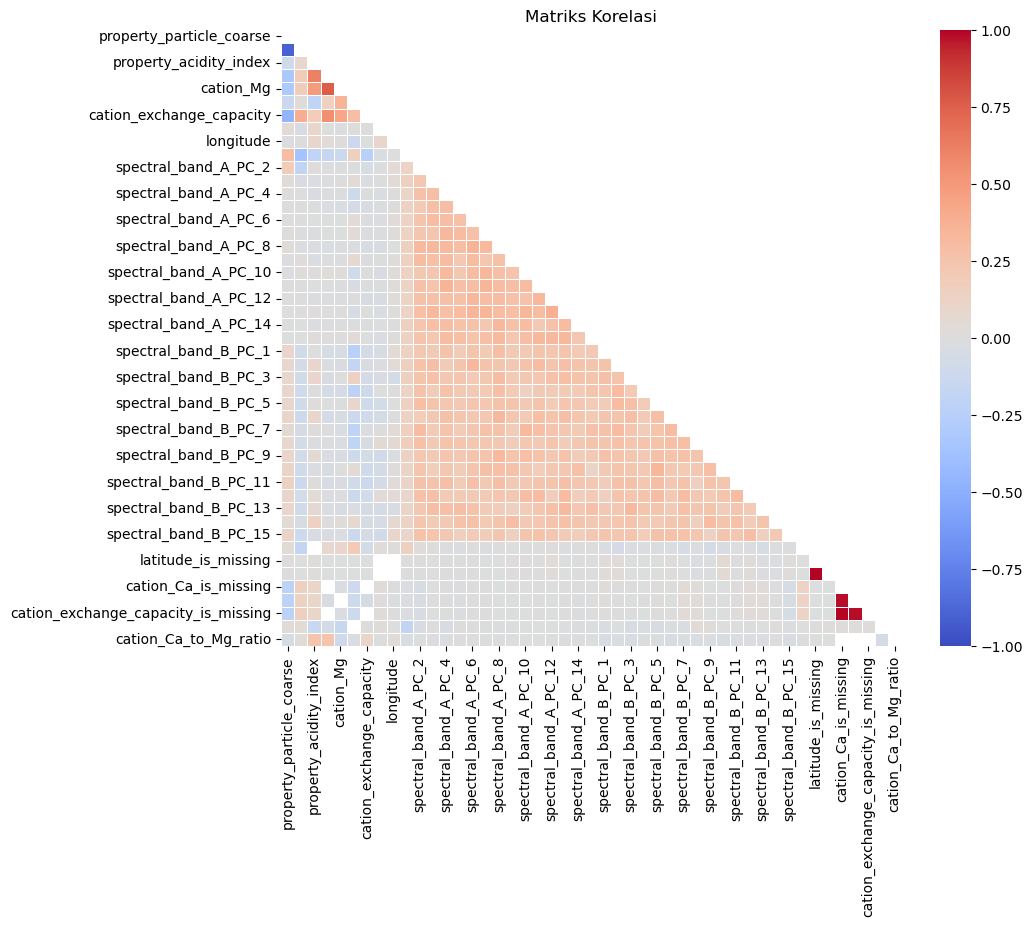

In [15]:
# Menghitung matriks korelasi
corr_matrix = X.corr(numeric_only=True)

# Membuat heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
    annot=False,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriks Korelasi")
plt.show()

Pemeriksaan matriks korelasi menunjukkan bahwa sebagian besar variabel pada dataset memiliki korelasi rendah hingga sedang. Namun demikian, terdapat dua pasangan variabel dengan korelasi yang tinggi, yaitu `property_particle_coarse` dengan `property_particle_fine` (r = −0,902) dan `cation_Ca` dengan `cation_Mg` (r = 0,763). Selain itu, beberapa pasangan variabel menunjukkan korelasi sedang hingga kuat, seperti `property_acidity_index` dengan `cation_Ca` (r = 0,614) serta `cation_exchange_capacity` dengan `cation_Ca` (r = 0,547). Hubungan-hubungan tersebut dapat dijelaskan berdasarkan karakteristik tanah. Fraksi partikel kasar dan halus merupakan komponen komplementer penyusun tekstur tanah sehingga secara alami menunjukkan korelasi negatif yang sangat kuat. Sementara itu, kapasitas tukar kation (KTK) merepresentasikan kemampuan tanah menahan kation-kation basa, sehingga hubungannya dengan konsentrasi Ca dan Mg sejalan dengan mekanisme pembentukan sifat kimia tanah.

Meskipun terdapat beberapa pasangan variabel yang berkorelasi tinggi, multikolinearitas tidak ditangani secara khusus melalui penghapusan fitur maupun regularisasi tambahan karena model utama yang digunakan adalah **CatBoost**, yaitu algoritma *gradient boosting* berbasis pohon keputusan (*tree-based ensemble*). Berbeda dengan model linier yang mengasumsikan independensi antar-prediktor, CatBoost membangun model melalui serangkaian pemisahan (*split*) nonlinier pada satu fitur setiap simpul, sehingga tidak sensitif terhadap keberadaan variabel yang saling berkorelasi. Temuan ini sejalan dengan hasil penelitian Uddin dan Lu (2024), yang menunjukkan bahwa karakteristik statistik dataset yang berkaitan dengan kolinearitas tidak memberikan pengaruh yang signifikan terhadap performa model berbasis pohon, berbeda dengan model seperti regresi logistik, SVM, dan KNN yang lebih rentan terhadap multikolinearitas.

Namun demikian, keberadaan variabel yang berkorelasi tinggi tetap perlu diperhatikan pada tahap interpretasi model. Wallace et al. (2023) menjelaskan bahwa pada model berbasis pohon, fitur-fitur yang berkorelasi tinggi cenderung saling berbagi kontribusi dalam proses pembentukan model sehingga nilai *feature importance* dapat tersebar di antara fitur-fitur tersebut. Akibatnya, besarnya nilai *feature importance* tidak selalu mencerminkan kontribusi unik masing-masing variabel. Oleh karena itu, pada penelitian ini korelasi tinggi dipandang sebagai karakteristik alami data yang tidak memerlukan mitigasi untuk meningkatkan akurasi prediksi CatBoost, tetapi perlu dipertimbangkan ketika menginterpretasikan hasil *feature importance*.

Daftar pustaka untuk RQ2:

Uddin, S., & Lu, H. (2024). Dataset meta-level and statistical features affect machine learning performance. Scientific Reports, 14. https://doi.org/10.1038/s41598-024-51825-x
Wallace, M., Mentch, L., Wheeler, B., Tapia, A. L., Richards, M., Zhou, S., Yi, L., Redline, S., & Buysse, D. J. (2023). Use and misuse of random forest variable importance metrics in medicine: demonstrations through incident stroke prediction. BMC Medical Research Methodology, 23. https://doi.org/10.1186/s12874-023-01965-x

# RQ7
---
Fitur baru apa saja yang Anda buat melalui proses feature engineering? Jelaskan bagaimana fitur tersebut meningkatkan pemahaman model terhadap pola kandungan organik tanah!

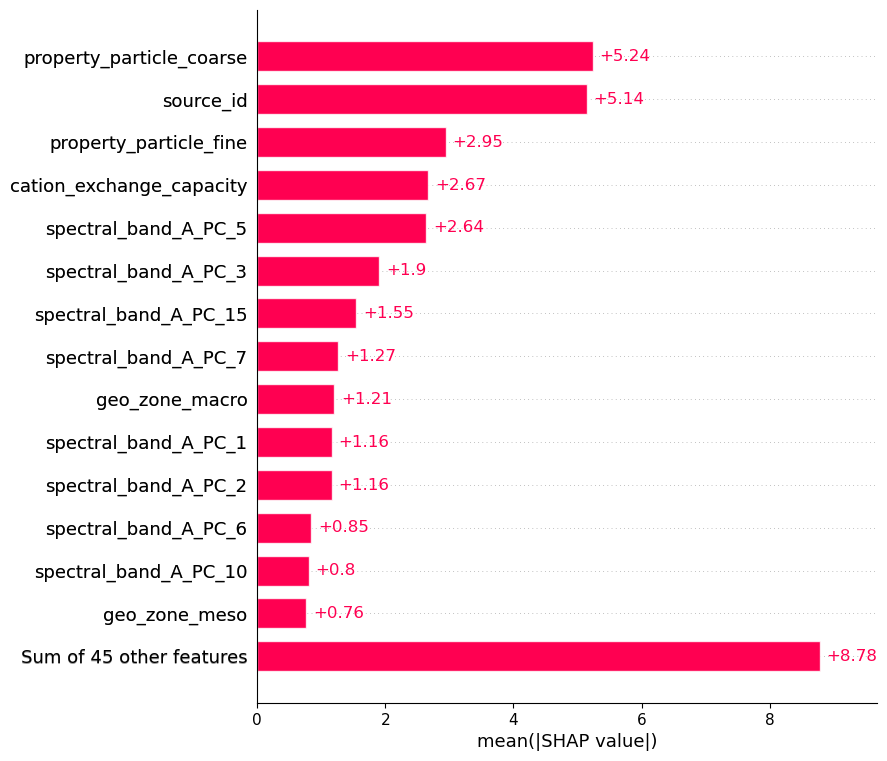

In [ ]:
shap.plots.bar(shap_values, max_display=15)

In [4]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X.columns,
).sort_values(ascending=False)

rank = mean_abs_shap.rank(ascending=False).astype(int)

engineered_feats = ["n_bands_available", "cation_Ca_to_Mg_ratio"] + [
    c for c in X.columns if c.endswith("_is_missing")
]

print(f"Peringkat fitur hasil feature engineering (dari {len(mean_abs_shap)} total fitur):\n")
for feat in engineered_feats:
    print(f"{feat:35s} -> peringkat #{rank[feat]:2d}  (mean |SHAP| = {mean_abs_shap[feat]:.4f})")

Peringkat fitur hasil feature engineering (dari 59 total fitur):

n_bands_available                   -> peringkat #51  (mean |SHAP| = 0.0108)
cation_Ca_to_Mg_ratio               -> peringkat #24  (mean |SHAP| = 0.4039)
property_acidity_index_is_missing   -> peringkat #50  (mean |SHAP| = 0.0110)
latitude_is_missing                 -> peringkat #56  (mean |SHAP| = 0.0000)
longitude_is_missing                -> peringkat #56  (mean |SHAP| = 0.0000)
cation_Ca_is_missing                -> peringkat #33  (mean |SHAP| = 0.1066)
cation_Mg_is_missing                -> peringkat #40  (mean |SHAP| = 0.0477)
cation_exchange_capacity_is_missing -> peringkat #56  (mean |SHAP| = 0.0000)
cation_Na_is_missing                -> peringkat #56  (mean |SHAP| = 0.0000)


Pada proses *feature engineering*, dibuat tiga kelompok fitur baru untuk memperkaya informasi yang digunakan model. Pertama, ditambahkan fitur indikator *missingness* (`*_is_missing`) pada tujuh atribut yang memiliki nilai hilang agar model dapat mengenali pola kehilangan data yang berpotensi bersifat informatif (*informative missingness*), terutama karena perbedaan sumber data dan instrumen pengukuran (Sisk et al., 2023). Kedua, dibuat fitur `n_bands_available`, yaitu jumlah ketersediaan spektrum A dan B, sehingga model memperoleh informasi mengenai tingkat kelengkapan data spektral setiap sampel dalam satu variabel. Ketiga, dibuat fitur `cation_Ca_to_Mg_ratio` yang merepresentasikan keseimbangan antara kalsium (Ca) dan magnesium (Mg). Rasio ini dipilih karena mampu menangkap hubungan antar kation yang tidak tercermin dari nilai absolut masing-masing, serta berkaitan dengan kondisi kimia tanah yang memengaruhi retensi hara, aktivitas mikroorganisme, dan proses dekomposisi bahan organik (Maciel et al., 2024). Secara keseluruhan, fitur-fitur tersebut dirancang untuk memberikan representasi data yang lebih informatif sehingga model memiliki peluang lebih baik dalam mengenali pola kandungan organik tanah.

Berdasarkan analisis SHAP, fitur `cation_Ca_to_Mg_ratio` merupakan fitur hasil *feature engineering* yang paling berkontribusi terhadap prediksi, sedangkan `n_bands_available` dan sebagian besar indikator *missingness* memberikan kontribusi yang relatif kecil. Hal ini menunjukkan bahwa tidak semua fitur hasil *feature engineering* dimanfaatkan model dengan tingkat yang sama.

Daftar pustaka untuk RQ3:

Maciel, A. P. C., Medeiros, G., De Souza Machado, A., Pilatti, M. C., Reis, R. D. R., & Sampaio, S. C. (2024). The Impact of 9 Years of Swine Wastewater Application on the Mineral and Organic Quality of Soil in Various Agricultural Crops. Water, 16. https://doi.org/10.3390/w16101412
Sisk, R., Sperrin, M., Peek, N., Van Smeden, M., & Martin, G. (2023). Imputation and missing indicators for handling missing data in the development and deployment of clinical prediction models: A simulation study. Statistical Methods in Medical Research, 32, 1461–1477. https://doi.org/10.1177/09622802231165001

# RQ8
---
Jelaskan model yang Anda gunakan dalam memprediksi kandungan organik tanah! Mengapa Anda memilih model tersebut dibanding alternatif lain, khususnya dalam konteks data yang memiliki representasi spektral?

In [5]:
# Cek persentase missing value per kolom
missing_pct = train.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.head(20))

cation_Na                 96.413916
spectral_band_B_PC_14     84.888492
spectral_band_B_PC_15     84.888492
spectral_band_B_PC_12     84.888492
spectral_band_B_PC_1      84.888492
spectral_band_B_PC_2      84.888492
spectral_band_B_PC_3      84.888492
spectral_band_B_PC_4      84.888492
spectral_band_B_PC_5      84.888492
spectral_band_B_PC_6      84.888492
spectral_band_B_PC_7      84.888492
spectral_band_B_PC_8      84.888492
spectral_band_B_PC_13     84.888492
spectral_band_B_PC_9      84.888492
spectral_band_B_PC_11     84.888492
spectral_band_B_PC_10     84.888492
longitude                 78.679750
latitude                  78.679750
property_acidity_index    74.977698
cation_Ca_to_Mg_ratio     11.186441
dtype: float64


In [6]:
# Korelasi linear PCA spektral Band A dengan target
pcA_cols = [c for c in train.columns if c.startswith('spectral_band_A_PC')]
corr_pcA = train[pcA_cols + ["property_organic_content"]].corr()["property_organic_content"].drop("property_organic_content")
print(corr_pcA.sort_values(key=abs, ascending=False))

spectral_band_A_PC_1    -0.224427
spectral_band_A_PC_2    -0.074124
spectral_band_A_PC_3    -0.053213
spectral_band_A_PC_5    -0.027229
spectral_band_A_PC_8    -0.018338
spectral_band_A_PC_7    -0.016315
spectral_band_A_PC_10    0.013145
spectral_band_A_PC_15    0.009704
spectral_band_A_PC_12   -0.007914
spectral_band_A_PC_6     0.002654
spectral_band_A_PC_9     0.002250
spectral_band_A_PC_14   -0.001789
spectral_band_A_PC_11   -0.001635
spectral_band_A_PC_13   -0.001279
spectral_band_A_PC_4    -0.000611
Name: property_organic_content, dtype: float64


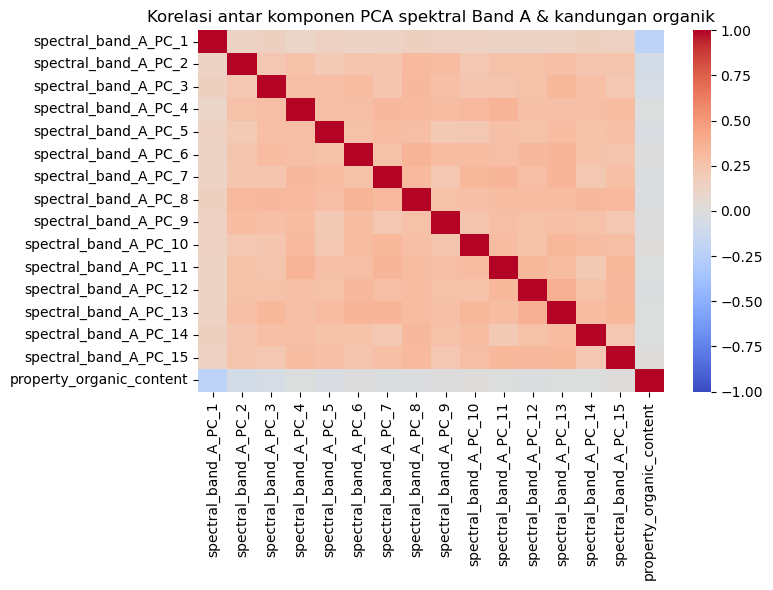

In [7]:
# Visualisasi: heatmap korelasi antar komponen PCA spektral Band A dan target
plt.figure(figsize=(8, 6))
corr_matrix = train[pcA_cols + ["property_organic_content"]].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", vmin=-1, center=0, vmax=1, annot=False)
plt.title("Korelasi antar komponen PCA spektral Band A & kandungan organik")
plt.tight_layout()
plt.show()

In [8]:
# Cek ketersediaan Band A vs Band B
print(f"{train['has_band_A_spectrum'].value_counts()}\n")
print(f"{train['has_band_B_spectrum'].value_counts()}")

has_band_A_spectrum
YES    11210
Name: count, dtype: int64

has_band_B_spectrum
NO     9986
YES    1224
Name: count, dtype: int64


Komponen dengan |korelasi linear| tertinggi: spectral_band_A_PC_1 (r = -0.2244)


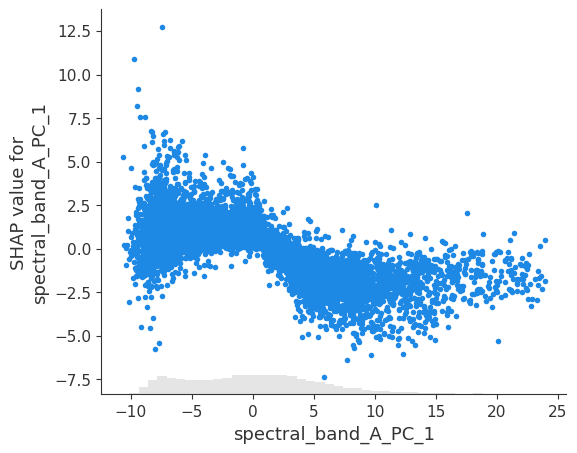

In [ ]:
# Komponen PCA Band A dengan korelasi linear tertinggi
top_corr_pc = corr_pcA.sort_values(key=abs, ascending=False).index[0]
print(f"Komponen dengan |korelasi linear| tertinggi: {top_corr_pc} (r = {corr_pcA[top_corr_pc]:.4f})")

shap.plots.scatter(shap_values[:, top_corr_pc])


In [ ]:
shap_rank_pcA = (
    pd.Series(np.abs(shap_values.values).mean(axis=0), index=X.columns)
    .loc[pcA_cols]
    .rank(ascending=False)
    .astype(int)
)
corr_rank_pcA = corr_pcA.abs().rank(ascending=False).astype(int)

comparison = pd.DataFrame(
    {
        "|korelasi linear|": corr_pcA.abs().round(4),
        "peringkat korelasi": corr_rank_pcA,
        "peringkat SHAP": shap_rank_pcA,
    }
).sort_values("peringkat SHAP")

print(comparison)

                       |korelasi linear|  peringkat korelasi  peringkat SHAP
spectral_band_A_PC_5              0.0272                   4               1
spectral_band_A_PC_3              0.0532                   3               2
spectral_band_A_PC_15             0.0097                   8               3
spectral_band_A_PC_7              0.0163                   6               4
spectral_band_A_PC_1              0.2244                   1               5
spectral_band_A_PC_2              0.0741                   2               6
spectral_band_A_PC_6              0.0027                  10               7
spectral_band_A_PC_10             0.0131                   7               8
spectral_band_A_PC_8              0.0183                   5               9
spectral_band_A_PC_9              0.0022                  11              10
spectral_band_A_PC_12             0.0079                   9              11
spectral_band_A_PC_4              0.0006                  15              12

* Korelasi linear antara PCA spektral Band A dengan target tergolong lemah ($|r|$ maksimum ~0,22), mengindikasikan bahwa hubungan antara kedua kumpulan peubah ini kemungkinan bersifat non-linear atau berinteraksi dengan fitur lain. Temuan ini sejalan dengan Padarian et al. (2020), yang mengonfirmasi bahwa hubungan antara reflektansi spektral inframerah dengan sifat kimia tanah bersifat non-linear tingkat tinggi.
* `spectral_band_B`, `latitude`/`longitude`, dan `acidity_index` memiliki proporsi missing yang besar (70–85%) dan berpotensi menunjukkan *informative missingness* yang terkait dengan sumber data.
* Kombinasi non-linearitas, data hilang yang terstruktur, dan fitur kategorikal-numerik yang campuran menjadi dasar argumentasi mengapa model berbasis **tree ensemble** (misalnya Gradient Boosting) lebih sesuai dibandingkan model linear atau PLSR klasik.

# RQ9
---
Menurut Anda, apakah metrik penilaian RMSE tepat untuk kasus prediksi kandungan organik tanah ini? Jika tidak, metrik apa yang lebih tepat? Elaborasikan jawaban Anda dengan mempertimbangkan karakteristik distribusi target!

RMSE tidak sepenuhnya tepat sebagai metrik tunggal dalam konteks prediksi kandungan bahan organik tanah. Argumentasi ini bergantung pada karakteristik distribusi target yang perlu dipahami terlebih dahulu.

## Distribusi Target

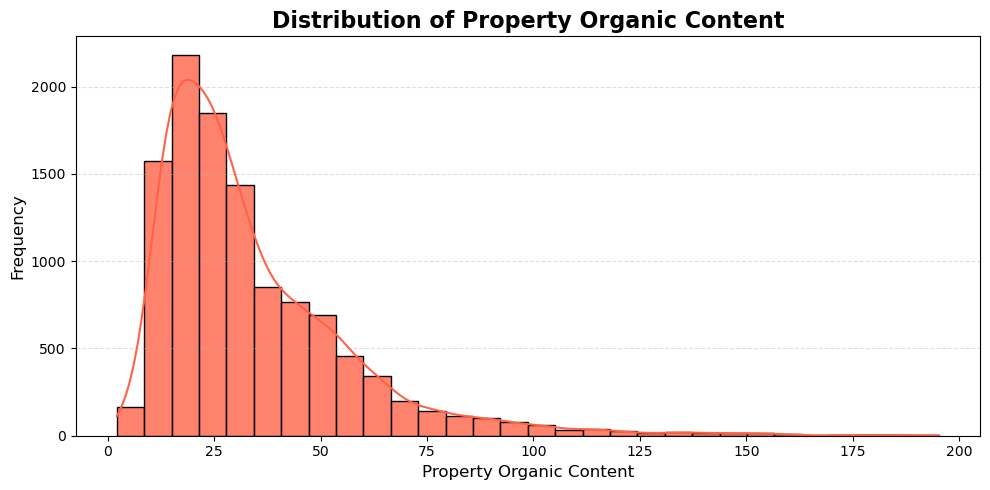

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x="property_organic_content",
    bins=30,
    kde=True,
    color="tomato",
    edgecolor="black",
    alpha=0.8,
)

plt.title("Distribution of Property Organic Content", fontsize=16, fontweight="bold")
plt.xlabel("Property Organic Content", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

Data `property_organic_content` secara empiris memiliki beberapa sifat khas yang memengaruhi pemilihan metrik:
* **Right-skewed:** Sebagian besar sampel tanah pertanian di daerah tropis memiliki kandungan organik yang relatif rendah hingga sedang, sementara sampel dari lahan gambut, hutan primer, atau ekosistem basah bisa memiliki nilai yang sangat tinggi. Hal ini membentuk distribusi dengan ekor panjang di sisi kanan.
* **Adanya** ***outlier*** **ekstrem:** Lahan gambut (*peatlands*) atau hutan tropis dapat memiliki kandungan organik yang jauh melampaui rata-rata, membentuk titik-titik pencilan yang signifikan.
* **Nilai terbatas pada domain positif:** Kandungan organik tidak mungkin bernilai negatif, yang secara alami menyarankan penggunaan transformasi logaritmik dalam pemodelan maupun evaluasi.

## Keterbatasan RMSE pada Studi Kasus Ini

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

Karena setiap selisih dikuadratkan, *outlier* mendapat penalti yang tidak proporsional. Langkah penguadratan memberikan bobot yang tidak proporsional terhadap kesalahan besar — jika sebagian besar prediksi meleset 2–3 satuan namun satu prediksi meleset 50 satuan, pencilan tunggal itu akan dikuadratkan menjadi 2.500 sebelum dirata-ratakan, sehingga menarik nilai RMSE ke atas secara signifikan meskipun model bekerja baik pada sebagian besar data. Pada distribusi yang *right-skewed* seperti kandungan organik tanah, kondisi ini membuat model yang sebenarnya baik terlihat buruk secara metrik hanya karena gagal pada segelintir sampel bernilai sangat tinggi.

Selain itu, RMSE tidak bersifat *scale-invariant*: nilai RMSE tidak dapat dibandingkan secara langsung antar dataset yang memiliki skala target berbeda, karena tidak dinormalisasi terhadap rentang atau sebaran nilai target (DataCamp, 2025).

## Rekomendasi Metrik Evaluasi yang Lebih Sesuai

**RMSLE (Rekomendasi Utama)**

$$
\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(\log(y_i + 1) - \log(\hat{y}_i + 1)\right)^2}
$$

RMSLE pada dasarnya adalah RMSE yang dihitung pada ruang logaritmik, transformasi ini memungkinkan penanganan *relative error* yang lebih baik dan membuat metrik lebih *robust* terhadap *outlier*, khususnya ketika prediksi dan nilai aktual sama-sama besar. Penambahan 1 di dalam logaritma memastikan nilai nol tetap dapat ditangani tanpa masalah komputasional (Ciampiconi et al, 2024). Secara konkret, RMSLE:
* Mengurangi dampak *outlier* dengan nilai sangat tinggi
* Membuat penalti bersifat relatif terhadap skala nilai aktual, RMSLE mengukur perbedaan berbasis rasio antara nilai prediksi dan aktual, bukan selisih absolutnya, sehingga kesalahan 10% pada kandungan organik rendah dihukum setara dengan kesalahan 10% pada kandungan organik tinggi.
* Sesuai dengan sifat alamiah distribusi peubah respon yang *right-skewed*

**MAE (Metrik Komplementer)**

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

MAE memberikan interpretasi yang intuitif karena menggunakan selisih absolut tanpa penguadratan, sehingga setiap kesalahan mendapat bobot yang sama dan metrik ini tidak terpengaruh secara berlebihan oleh *outlier* seperti halnya MSE. Selain itu, karena dinyatakan dalam satuan yang sama dengan peubah respon, MAE mudah dipahami dan dikomunikasikan (NumberAnalytics, 2025).

**$R^2$ (Ukuran Kekuatan Penjelas)**

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

$R^2$ mengukur proporsi ragam dalam peubah respon yang berhasil dijelaskan oleh model, dan nilainya tidak bergantung pada skala peubah penjelas, sehingga model dengan $R^2$ tinggi menunjukkan prediksi yang baik terlepas dari satuan pengukuran yang digunakan (Chicco, 2021). Metrik ini relevan untuk mengomunikasikan kualitas model kepada audiens kebijakan dan non-teknis.

# RQ10 
---
Jika Anda boleh mengambil data eksternal, data tentang apa yang akan Anda ambil untuk meningkatkan akurasi prediksi kandungan organik tanah? Jelaskan alasan pemilihannya dan bagaimana data tersebut dapat diintegrasikan ke dalam pipeline pemodelan Anda!

Jika diperbolehkan mengambil data eksternal, dua jenis data yang diprioritaskan adalah data iklim (curah hujan dan suhu) serta indeks vegetasi berbasis citra satelit (NDVI). Pemilihan ini didasarkan pada kerangka kerja scorpan dalam pemetaan tanah digital, di mana sifat tanah dipandang sebagai fungsi dari beberapa faktor pembentuk, termasuk *climate* dan *organisms*; dataset kompetisi saat ini sudah merepresentasikan faktor tanah (`property_*`), batuan induk (`parent_rock_type`), dan posisi spasial (`latitude`, `longitude`, `geo_zone_*`), namun belum memiliki representasi langsung untuk faktor iklim dan vegetasi yang memengaruhi laju dekomposisi dan input bahan organik ke tanah. Data curah hujan dan suhu dipilih karena keduanya berulang kali terbukti sebagai prediktor berpengaruh pada pemodelan kandungan karbon organik tanah; pada studi di Iran bagian barat, curah hujan dan suhu udara menjadi variabel auksiler dengan peringkat kontribusi tertinggi, masing-masing menyumbang 27,09% dan 20,18% terhadap keragaman karbon organik tanah (Mahmoudzadeh et al., 2020). Sementara itu, indeks vegetasi NDVI dipilih sebagai proksi input biomassa ke tanah, dengan penekanan pada agregasi *time-series* sepanjang musim tanam, bukan citra satu waktu pengambilan sampel — pendekatan ini terbukti memberikan peningkatan akurasi yang jauh lebih besar dibanding NDVI snapshot tunggal, dengan satu studi pemetaan karbon organik tanah di area dataran melaporkan peningkatan $R^2$ sebesar 65,45% dan penurunan RMSE sebesar 47,12% setelah fitur *time-series* ditambahkan (Yan et al., 2025).

Integrasi kedua data tersebut ke dalam pipeline pemodelan dapat dilakukan melalui ekstraksi nilai raster berbasis koordinat (*point sampling*), memanfaatkan kolom `latitude` dan `longitude` yang sudah tersedia pada dataset. Nilai curah hujan dan suhu dapat diekstraksi dari basis data klimatologi grid global (misalnya WorldClim atau CHIRPS) pada koordinat tiap sampel, sementara nilai NDVI agregat dapat diekstraksi dari arsip citra satelit (misalnya Sentinel-2 atau MODIS) menggunakan rentang waktu yang relevan terhadap musim tanam di lokasi tersebut. Hasil ekstraksi ini kemudian digabungkan (*join*) sebagai kolom numerik tambahan ke dataframe yang sama, sehingga tetap kompatibel dengan format tabular yang dibutuhkan CatBoost tanpa memerlukan perubahan arsitektur model. Satu hal yang perlu diperhatikan dalam implementasinya adalah kesesuaian waktu (*temporal alignment*) antara periode pengambilan data eksternal dan waktu pengambilan sampel tanah, mengingat data iklim dan vegetasi bersifat dinamis terhadap waktu sedangkan dataset kompetisi ini tidak menyertakan informasi tanggal pengambilan sampel secara eksplisit.

Daftar pustaka untuk RQ4:

Mahmoudzadeh, H., Matinfar, H., Taghizadeh‐Mehrjardi, R., & Kerry, R. (2020). Spatial prediction of soil organic carbon using machine learning techniques in western Iran. Geoderma Regional. https://doi.org/10.1016/j.geodrs.2020.e00260
Yan, K., Wang, D., Feng, Y., Hou, S., Zhang, Y., & Yang, H. (2025). Digital mapping of soil organic carbon in a plain area based on time-series features. Ecological Indicators. https://doi.org/10.1016/j.ecolind.2025.113215

# Daftar Pustaka


Silva, L. C., et al. (2019). Dynamic of soil organic matter in tropical savannas and seasonal forests. Geoderma, 337, 45-55.

Amundson, R., et al. (2015). Soil and human security in the 21st century. Science, 348(6235), 1261071.

Roberts, D. R., et al. (2017). Cross-validation strategies for risk assessment of geographical features in machine learning. Ecography, 40(8), 913-929.

Padarian, J., McBratney, A. B., & Minasny, B. (2020). Game theory and machine learning for digital soil mapping. Soil Research, 58(8), 813-821.
